# **Cell 1 — Mount Drive**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Cell 2 — Markdown (Text cell)**

# 🌦️ Daily Delhi Climate - Data Preprocessing
## Part 1: Data Collection
- Source: Kaggle - Daily Delhi Climate Dataset
- Type: Real-world time-series weather data
- File: DailyDelhiClimateTest.csv

# **Cell 3 — Load & Explore**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv('/content/drive/MyDrive/Weather_project/DailyDelhiClimateTest.csv')
print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Types:")
print(df.info())
print("\nBasic Statistics:")
print(df.describe())

Shape: (114, 5)

First 5 rows:
         date   meantemp   humidity  wind_speed  meanpressure
0  2017-01-01  15.913043  85.869565    2.743478     59.000000
1  2017-01-02  18.500000  77.222222    2.894444   1018.277778
2  2017-01-03  17.111111  81.888889    4.016667   1018.333333
3  2017-01-04  18.700000  70.050000    4.545000   1015.700000
4  2017-01-05  18.388889  74.944444    3.300000   1014.333333

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          114 non-null    object 
 1   meantemp      114 non-null    float64
 2   humidity      114 non-null    float64
 3   wind_speed    114 non-null    float64
 4   meanpressure  114 non-null    float64
dtypes: float64(4), object(1)
memory usage: 4.6+ KB
None

Basic Statistics:
         meantemp    humidity  wind_speed  meanpressure
count  114.000000  114.000000  114.000000    11

# **Cell 4 — Markdown**

## Part 2: Data Preprocessing
### Step 1: Missing Values & Duplicates

# **Cell 5 — Missing Values & Duplicates**

In [3]:
print("Missing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)
print("After removing duplicates:", df.shape)

Missing Values:
date            0
meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64

Duplicate Rows: 0
After removing duplicates: (114, 5)


# **Cell 6 — Markdown**

### Step 2: Fix Outlier in meanpressure

# **Cell 7 — Fix Outlier**

In [4]:
print("Before fix - Min pressure:", df['meanpressure'].min())
df['meanpressure'] = df['meanpressure'].apply(
    lambda x: df['meanpressure'].median() if x < 900 else x
)
print("After fix - Min pressure:", df['meanpressure'].min())

Before fix - Min pressure: 59.0
After fix - Min pressure: 998.625


# **Cell 8 — Markdown**

### Step 3: Date Parsing & Feature Extraction

# **Cell 9 — Date Parsing**

In [5]:
df['date'] = pd.to_datetime(df['date'])
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
print(df.head())

        date   meantemp   humidity  wind_speed  meanpressure  month  day
0 2017-01-01  15.913043  85.869565    2.743478   1012.739316      1    1
1 2017-01-02  18.500000  77.222222    2.894444   1018.277778      1    2
2 2017-01-03  17.111111  81.888889    4.016667   1018.333333      1    3
3 2017-01-04  18.700000  70.050000    4.545000   1015.700000      1    4
4 2017-01-05  18.388889  74.944444    3.300000   1014.333333      1    5


# **Cell 10 — Markdown**

### Step 4: Annotation - Creating Labels

# **Cell 11 — Create Labels**

In [6]:
df['season'] = df['month'].apply(lambda m:
    'Winter' if m in [12, 1, 2] else
    'Spring' if m in [3, 4, 5] else
    'Summer' if m in [6, 7, 8] else 'Autumn'
)

df['temp_label'] = pd.cut(
    df['meantemp'],
    bins=[0, 15, 25, 50],
    labels=['Cold', 'Mild', 'Hot']
)

print(df[['date', 'meantemp', 'season', 'temp_label']].head(10))
print("\nSeason counts:\n", df['season'].value_counts())
print("\nTemp label counts:\n", df['temp_label'].value_counts())

        date   meantemp  season temp_label
0 2017-01-01  15.913043  Winter       Mild
1 2017-01-02  18.500000  Winter       Mild
2 2017-01-03  17.111111  Winter       Mild
3 2017-01-04  18.700000  Winter       Mild
4 2017-01-05  18.388889  Winter       Mild
5 2017-01-06  19.318182  Winter       Mild
6 2017-01-07  14.708333  Winter       Cold
7 2017-01-08  15.684211  Winter       Mild
8 2017-01-09  14.571429  Winter       Cold
9 2017-01-10  12.111111  Winter       Cold

Season counts:
 season
Winter    59
Spring    55
Name: count, dtype: int64

Temp label counts:
 temp_label
Mild    67
Hot     34
Cold    13
Name: count, dtype: int64


# **Cell 12 — Markdown**

### Step 5: Normalization

# **Cell 13 — Normalize**

In [7]:
scaler = MinMaxScaler()
features = ['meantemp', 'humidity', 'wind_speed', 'meanpressure']
df[features] = scaler.fit_transform(df[features])

print("After Normalization:")
print(df[features].head())
print("\nMin values:\n", df[features].min())
print("\nMax values:\n", df[features].max())

After Normalization:
   meantemp  humidity  wind_speed  meanpressure
0  0.209066  0.872396    0.075640      0.583609
1  0.319149  0.761651    0.084061      0.812618
2  0.260047  0.821416    0.146661      0.814915
3  0.327660  0.669797    0.176133      0.706030
4  0.314421  0.732480    0.106684      0.649520

Min values:
 meantemp        0.0
humidity        0.0
wind_speed      0.0
meanpressure    0.0
dtype: float64

Max values:
 meantemp        1.0
humidity        1.0
wind_speed      1.0
meanpressure    1.0
dtype: float64


# **Cell 14 — Markdown**

### Step 6: Visualization

# **Cell 15 — Plot 1**

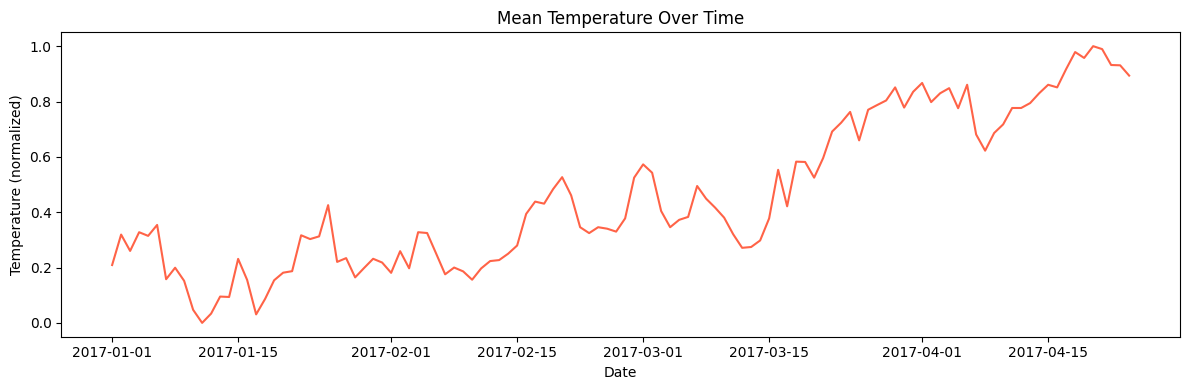

In [8]:
plt.figure(figsize=(12, 4))
plt.plot(df['date'], df['meantemp'], color='tomato')
plt.title('Mean Temperature Over Time')
plt.xlabel('Date')
plt.ylabel('Temperature (normalized)')
plt.tight_layout()
plt.show()

# **Cell 16 — Plot 2**

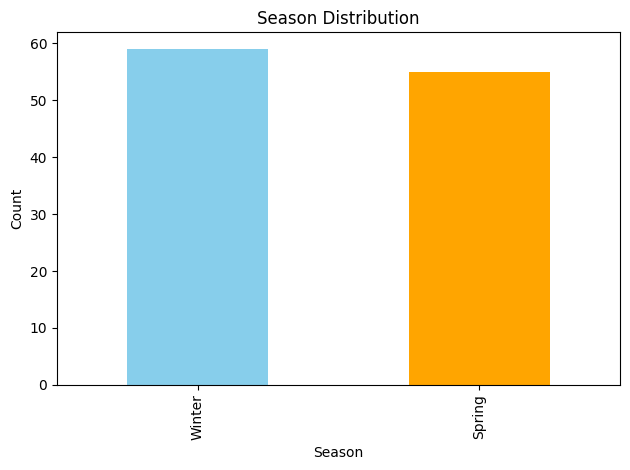

In [9]:
df['season'].value_counts().plot(kind='bar', color=['skyblue','orange'])
plt.title('Season Distribution')
plt.xlabel('Season')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# **Cell 17 — Plot 3**

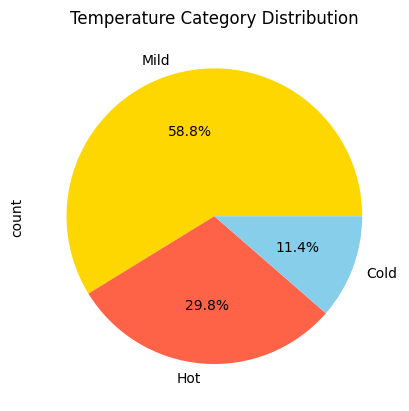

In [10]:
df['temp_label'].value_counts().plot(kind='pie', autopct='%1.1f%%',
    colors=['gold','tomato','skyblue'])
plt.title('Temperature Category Distribution')
plt.show()

# **Cell 18 — Plot 4**

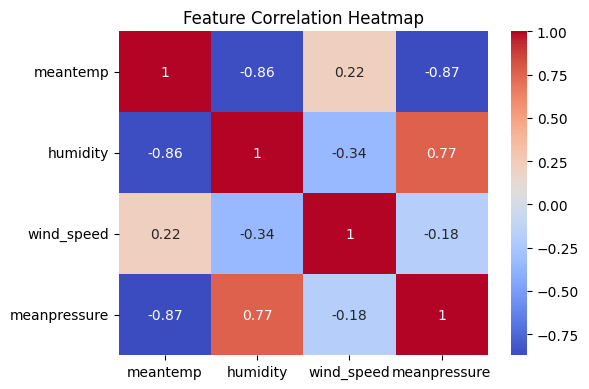

In [11]:
plt.figure(figsize=(6, 4))
sns.heatmap(df[['meantemp','humidity','wind_speed','meanpressure']].corr(),
    annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

# **Cell 19 — Markdown**

### Step 7: Save Cleaned Dataset

# **Cell 20 — Save**

In [12]:
df.to_csv('/content/drive/MyDrive/Weather_project/DailyDelhiClimate_Cleaned.csv', index=False)
print("✅ Cleaned dataset saved successfully!")
print("Final shape:", df.shape)
print("Columns:", df.columns.tolist())

✅ Cleaned dataset saved successfully!
Final shape: (114, 9)
Columns: ['date', 'meantemp', 'humidity', 'wind_speed', 'meanpressure', 'month', 'day', 'season', 'temp_label']


# **Cell 21 — Markdown:**

## Part 3: Model Selection
### Task: Classification (Cold / Mild / Hot temperature prediction)
### Dataset: Daily Delhi Climate (Cleaned)
### Models: Naive Bayes, Decision Tree, Random Forest, KNN, SVM

# **Cell 22 — Imports & Load Data:**

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load cleaned dataset
df_model = pd.read_csv('/content/drive/MyDrive/Weather_project/DailyDelhiClimate_Cleaned.csv')
print("Dataset loaded successfully!")
print("Shape:", df_model.shape)
print(df_model.head())

Dataset loaded successfully!
Shape: (114, 9)
         date  meantemp  humidity  wind_speed  meanpressure  month  day  \
0  2017-01-01  0.209066  0.872396    0.075640      0.583609      1    1   
1  2017-01-02  0.319149  0.761651    0.084061      0.812618      1    2   
2  2017-01-03  0.260047  0.821416    0.146661      0.814915      1    3   
3  2017-01-04  0.327660  0.669797    0.176133      0.706030      1    4   
4  2017-01-05  0.314421  0.732480    0.106684      0.649520      1    5   

   season temp_label  
0  Winter       Mild  
1  Winter       Mild  
2  Winter       Mild  
3  Winter       Mild  
4  Winter       Mild  


# **Cell 23 — Markdown:**

### Step 1: Feature & Target Selection

# **Cell 24 — Features & Target:**

In [14]:
# Features (input)
X = df_model[['humidity', 'wind_speed', 'meanpressure', 'month', 'day']]

# Target (output)
y = df_model['temp_label']

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (114, 5)
Target distribution:
 temp_label
Mild    67
Hot     34
Cold    13
Name: count, dtype: int64


# **Cell 25 — Markdown:**

### Step 2: Train / Validation / Test Split (70 / 15 / 15)

# **Cell 26 — Split Data:**

In [15]:
# First split: 70% train, 30% temp
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

# Second split: 15% val, 15% test from the 30% temp
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print("Train size:", X_train.shape[0])
print("Validation size:", X_val.shape[0])
print("Test size:", X_test.shape[0])

Train size: 79
Validation size: 17
Test size: 18


# **Cell 27 — Markdown:**

### Step 3: Model Training & Validation

# **Cell 28 — Train & Validate All Models:**

In [16]:
# Define all models
models = {
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', random_state=42)
}

# Train on train set, evaluate on validation set
val_results = {}
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred_val = model.predict(X_val)
    acc = accuracy_score(y_val, y_pred_val)
    val_results[name] = acc
    trained_models[name] = model
    print(f"\n{'='*40}")
    print(f"Model: {name}")
    print(f"Validation Accuracy: {acc*100:.2f}%")

# Find best model
best_model_name = max(val_results, key=val_results.get)
print(f"\n✅ Best Model on Validation: {best_model_name} → {val_results[best_model_name]*100:.2f}%")


Model: Naive Bayes
Validation Accuracy: 76.47%

Model: Decision Tree
Validation Accuracy: 64.71%

Model: Random Forest
Validation Accuracy: 64.71%

Model: KNN
Validation Accuracy: 64.71%

Model: SVM
Validation Accuracy: 47.06%

✅ Best Model on Validation: Naive Bayes → 76.47%


# **Cell 29 — Markdown:**

### Step 4: Performance Evaluation on Test Set

# **Cell 30 — Test Evaluation:**

In [17]:
# Use best model on test set
best_model = trained_models[best_model_name]
y_pred_test = best_model.predict(X_test)
test_acc = accuracy_score(y_test, y_pred_test)

print(f"Best Model: {best_model_name}")
print(f"Test Accuracy: {test_acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_test))

Best Model: Naive Bayes
Test Accuracy: 77.78%

Classification Report:
              precision    recall  f1-score   support

        Cold       0.40      1.00      0.57         2
         Hot       1.00      0.86      0.92         7
        Mild       0.86      0.67      0.75         9

    accuracy                           0.78        18
   macro avg       0.75      0.84      0.75        18
weighted avg       0.86      0.78      0.80        18



# **Cell 31 — Markdown:**

### Step 5: Performance Comparison (All Models)

# **Cell 32 — Comparison Table:**

In [18]:
# Show all models validation accuracy as table
results_df = pd.DataFrame({
    'Model': list(val_results.keys()),
    'Validation Accuracy (%)': [round(v*100, 2) for v in val_results.values()]
})
results_df = results_df.sort_values('Validation Accuracy (%)', ascending=False)
print(results_df.to_string(index=False))

        Model  Validation Accuracy (%)
  Naive Bayes                    76.47
Decision Tree                    64.71
Random Forest                    64.71
          KNN                    64.71
          SVM                    47.06


# **Cell 33 — Markdown:**

### Step 6: Visualizations

# **Cell 34 — Bar Chart (Model Comparison):**

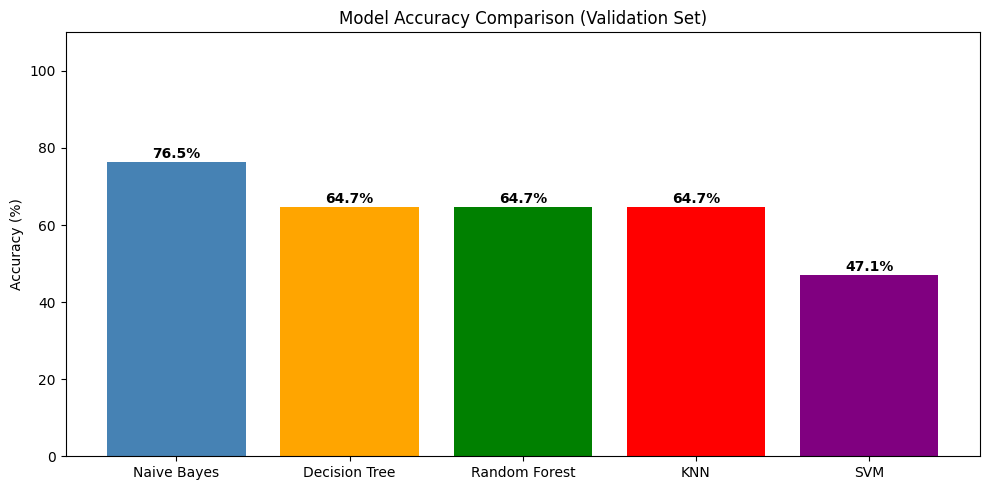

In [19]:
plt.figure(figsize=(10, 5))
colors = ['steelblue', 'orange', 'green', 'red', 'purple']
plt.bar(val_results.keys(), [v*100 for v in val_results.values()], color=colors)
plt.title('Model Accuracy Comparison (Validation Set)')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 110)
for i, (name, acc) in enumerate(val_results.items()):
    plt.text(i, acc*100 + 1, f'{acc*100:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# **Cell 35 — Confusion Matrix (Best Model):**

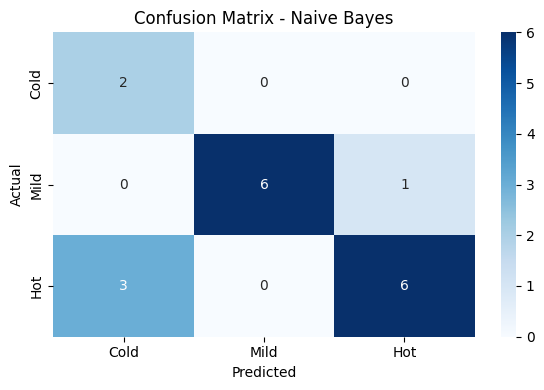

In [20]:
cm = confusion_matrix(y_test, y_pred_test)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Cold','Mild','Hot'],
            yticklabels=['Cold','Mild','Hot'])
plt.title(f'Confusion Matrix - {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# **Cell 36 — Markdown:**

part 4 - Model Training (Splitting - Train,Validation,Test):

### Step 7: Training Accuracy vs Validation Accuracy (Overfitting Check)

# **cell 37 : Train vs Validation Check:**

In [21]:
print("Training vs Validation Accuracy - Overfitting Check")
print("="*55)

train_results = {}
for name, model in trained_models.items():
    y_pred_train = model.predict(X_train)
    train_acc = accuracy_score(y_train, y_pred_train)
    val_acc = val_results[name]
    train_results[name] = train_acc

    diff = train_acc - val_acc
    status = "⚠️ Overfitting!" if diff > 0.15 else "✅ Balanced"

    print(f"\nModel: {name}")
    print(f"Train Accuracy:      {train_acc*100:.2f}%")
    print(f"Validation Accuracy: {val_acc*100:.2f}%")
    print(f"Gap:                 {diff*100:.2f}%  {status}")

Training vs Validation Accuracy - Overfitting Check

Model: Naive Bayes
Train Accuracy:      79.75%
Validation Accuracy: 76.47%
Gap:                 3.28%  ✅ Balanced

Model: Decision Tree
Train Accuracy:      100.00%
Validation Accuracy: 64.71%
Gap:                 35.29%  ⚠️ Overfitting!

Model: Random Forest
Train Accuracy:      100.00%
Validation Accuracy: 64.71%
Gap:                 35.29%  ⚠️ Overfitting!

Model: KNN
Train Accuracy:      83.54%
Validation Accuracy: 64.71%
Gap:                 18.84%  ⚠️ Overfitting!

Model: SVM
Train Accuracy:      63.29%
Validation Accuracy: 47.06%
Gap:                 16.23%  ⚠️ Overfitting!


# **Cell 38 — Markdown:**

### Step 8: Test Accuracy for ALL Models

# **Cell 39 — Test All Models:**

In [22]:
print("Test Accuracy - All Models")
print("="*40)

test_results = {}
for name, model in trained_models.items():
    y_pred_test_all = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred_test_all)
    test_results[name] = acc
    print(f"\nModel: {name}")
    print(f"Test Accuracy: {acc*100:.2f}%")
    print(classification_report(y_test, y_pred_test_all))

Test Accuracy - All Models

Model: Naive Bayes
Test Accuracy: 77.78%
              precision    recall  f1-score   support

        Cold       0.40      1.00      0.57         2
         Hot       1.00      0.86      0.92         7
        Mild       0.86      0.67      0.75         9

    accuracy                           0.78        18
   macro avg       0.75      0.84      0.75        18
weighted avg       0.86      0.78      0.80        18


Model: Decision Tree
Test Accuracy: 88.89%
              precision    recall  f1-score   support

        Cold       1.00      0.50      0.67         2
         Hot       1.00      0.86      0.92         7
        Mild       0.82      1.00      0.90         9

    accuracy                           0.89        18
   macro avg       0.94      0.79      0.83        18
weighted avg       0.91      0.89      0.88        18


Model: Random Forest
Test Accuracy: 83.33%
              precision    recall  f1-score   support

        Cold       0.00   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

#  Cell 40 — Markdown:

### Step 9: Full Summary Table (Train vs Validation vs Test)

# Cell 41 — Full Summary Table:

In [23]:
summary_df = pd.DataFrame({
    'Model': list(trained_models.keys()),
    'Train Acc (%)': [round(train_results[n]*100, 2)
                      for n in trained_models.keys()],
    'Val Acc (%)':   [round(val_results[n]*100, 2)
                      for n in trained_models.keys()],
    'Test Acc (%)':  [round(test_results[n]*100, 2)
                      for n in trained_models.keys()]
})
summary_df = summary_df.sort_values('Test Acc (%)', ascending=False)
print("\n📊 Full Model Performance Summary:")
print("="*55)
print(summary_df.to_string(index=False))

# Best model
best_test = summary_df.iloc[0]['Model']
best_acc = summary_df.iloc[0]['Test Acc (%)']
print(f"\n✅ Best Model Overall: {best_test} → {best_acc}% Test Accuracy")



📊 Full Model Performance Summary:
        Model  Train Acc (%)  Val Acc (%)  Test Acc (%)
Decision Tree         100.00        64.71         88.89
Random Forest         100.00        64.71         83.33
  Naive Bayes          79.75        76.47         77.78
          KNN          83.54        64.71         72.22
          SVM          63.29        47.06         50.00

✅ Best Model Overall: Decision Tree → 88.89% Test Accuracy


#  Cell 42 — Markdown:

In [24]:
### Step 10: Visualization - Train vs Val vs Test Comparison

# **Cell 43 — Grouped Bar Chart:**

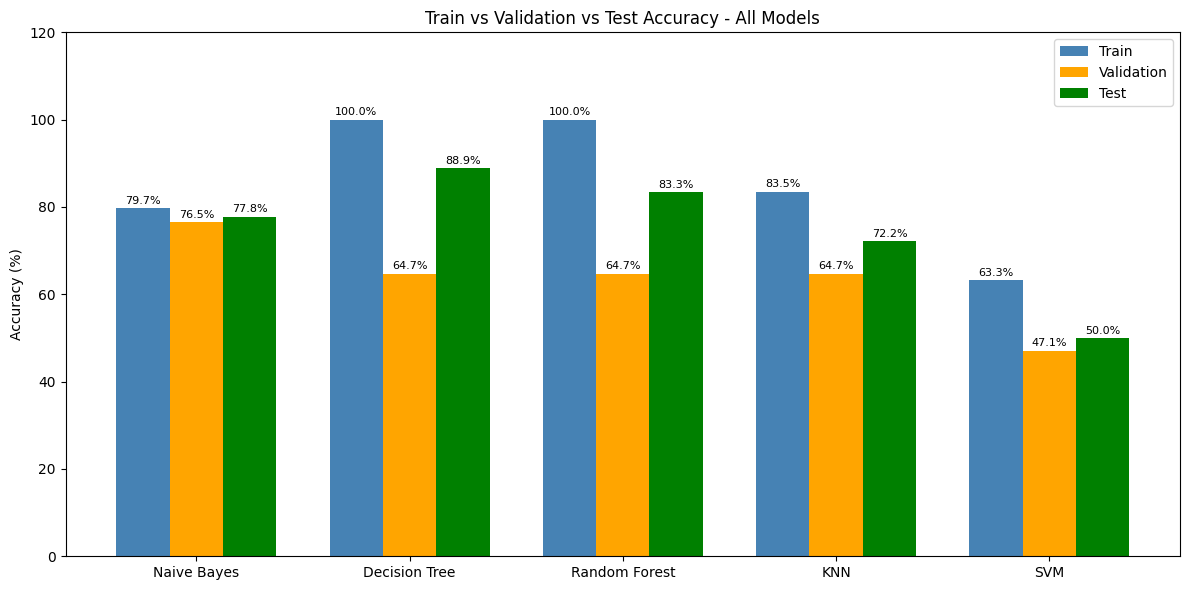

In [25]:
import numpy as np

models_names = list(trained_models.keys())
train_accs = [train_results[n]*100 for n in models_names]
val_accs = [val_results[n]*100 for n in models_names]
test_accs = [test_results[n]*100 for n in models_names]

x = np.arange(len(models_names))
width = 0.25

plt.figure(figsize=(12, 6))
plt.bar(x - width, train_accs, width, label='Train', color='steelblue')
plt.bar(x, val_accs, width, label='Validation', color='orange')
plt.bar(x + width, test_accs, width, label='Test', color='green')

plt.xticks(x, models_names)
plt.title('Train vs Validation vs Test Accuracy - All Models')
plt.ylabel('Accuracy (%)')
plt.ylim(0, 120)
plt.legend()

for i in range(len(models_names)):
    plt.text(i - width, train_accs[i] + 1,
             f'{train_accs[i]:.1f}%', ha='center', fontsize=8)
    plt.text(i, val_accs[i] + 1,
             f'{val_accs[i]:.1f}%', ha='center', fontsize=8)
    plt.text(i + width, test_accs[i] + 1,
             f'{test_accs[i]:.1f}%', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

# **Cell 44 — Confusion Matrix ALL Models:**

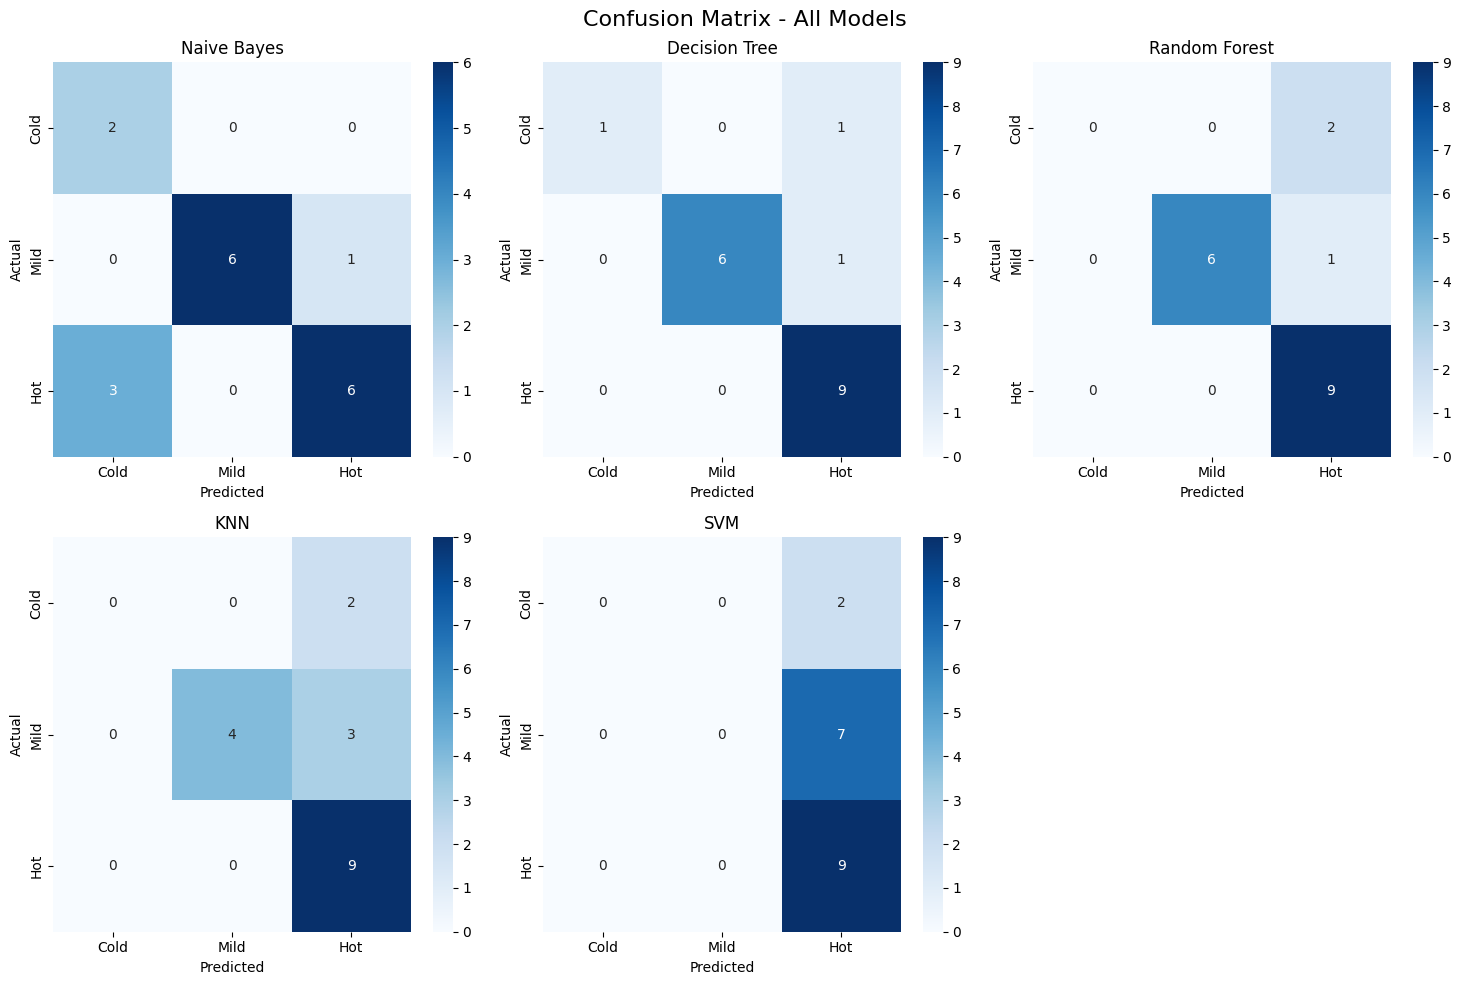

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Cold','Mild','Hot'],
                yticklabels=['Cold','Mild','Hot'],
                ax=axes[i])
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide empty 6th subplot
axes[5].set_visible(False)

plt.suptitle('Confusion Matrix - All Models', fontsize=16)
plt.tight_layout()
plt.show()

# **Cell 45 — Markdown:**

## Part 5: Performance Evaluation (on the Test Set)
### Evaluating all 5 models on the final unseen Test Set

# **Cell 46 — Detailed Test Evaluation ALL Models:**

In [27]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score

print("PART 5: PERFORMANCE EVALUATION ON TEST SET")
print("="*55)

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    print(f"\n{'='*55}")
    print(f"  Model: {name}")
    print(f"{'='*55}")
    print(f"  Accuracy:  {acc*100:.2f}%")
    print(f"  Precision: {precision*100:.2f}%")
    print(f"  Recall:    {recall*100:.2f}%")
    print(f"  F1 Score:  {f1*100:.2f}%")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

PART 5: PERFORMANCE EVALUATION ON TEST SET

  Model: Naive Bayes
  Accuracy:  77.78%
  Precision: 86.19%
  Recall:    77.78%
  F1 Score:  79.75%

  Classification Report:
              precision    recall  f1-score   support

        Cold       0.40      1.00      0.57         2
         Hot       1.00      0.86      0.92         7
        Mild       0.86      0.67      0.75         9

    accuracy                           0.78        18
   macro avg       0.75      0.84      0.75        18
weighted avg       0.86      0.78      0.80        18


  Model: Decision Tree
  Accuracy:  88.89%
  Precision: 90.91%
  Recall:    88.89%
  F1 Score:  88.30%

  Classification Report:
              precision    recall  f1-score   support

        Cold       1.00      0.50      0.67         2
         Hot       1.00      0.86      0.92         7
        Mild       0.82      1.00      0.90         9

    accuracy                           0.89        18
   macro avg       0.94      0.79      0.83   

# **Cell 47 — Markdown:**

### Performance Metrics Summary Table

# **Cell 48 — Metrics Summary Table:**

In [28]:
# Build complete metrics table
metrics_data = []

for name, model in trained_models.items():
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    metrics_data.append({
        'Model': name,
        'Accuracy (%)': round(acc*100, 2),
        'Precision (%)': round(precision*100, 2),
        'Recall (%)': round(recall*100, 2),
        'F1 Score (%)': round(f1*100, 2)
    })

metrics_df = pd.DataFrame(metrics_data)
metrics_df = metrics_df.sort_values('Accuracy (%)', ascending=False)
print("\n📊 Complete Performance Metrics - Test Set:")
print("="*70)
print(metrics_df.to_string(index=False))

# Print best model
best = metrics_df.iloc[0]
print(f"\n✅ Best Model: {best['Model']}")
print(f"   Accuracy:  {best['Accuracy (%)']}%")
print(f"   F1 Score:  {best['F1 Score (%)']}%")


📊 Complete Performance Metrics - Test Set:
        Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)
Decision Tree         88.89          90.91       88.89         88.30
Random Forest         83.33          76.39       83.33         78.75
  Naive Bayes         77.78          86.19       77.78         79.75
          KNN         72.22          71.03       72.22         67.41
          SVM         50.00          25.00       50.00         33.33

✅ Best Model: Decision Tree
   Accuracy:  88.89%
   F1 Score:  88.3%


# **Cell 49 — Markdown:**

### Visualization 1: Test Accuracy Comparison

# **Cell 50 — Test Accuracy Bar Chart:**


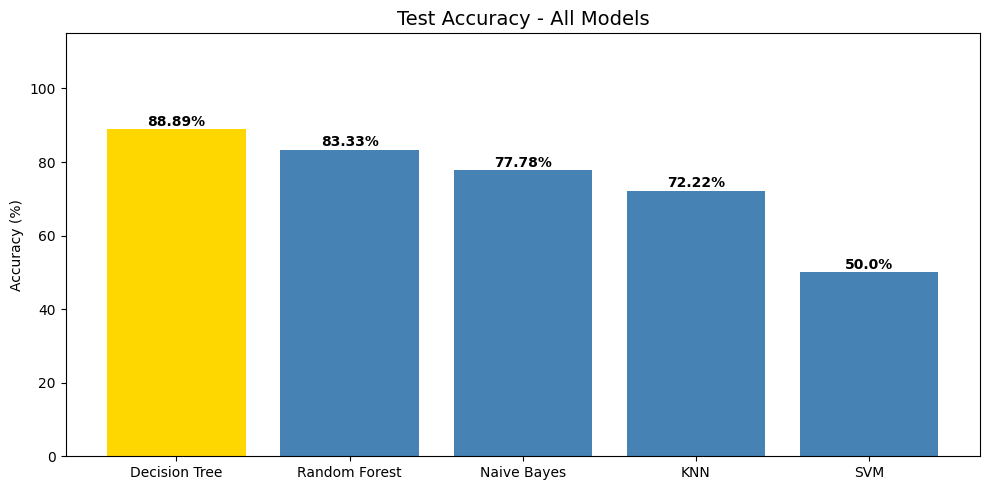

🥇 Gold bar = Best Model


In [29]:
models_list = metrics_df['Model'].tolist()
acc_list = metrics_df['Accuracy (%)'].tolist()

plt.figure(figsize=(10, 5))
colors = ['gold' if m == metrics_df.iloc[0]['Model']
          else 'steelblue' for m in models_list]
bars = plt.bar(models_list, acc_list, color=colors)
plt.title('Test Accuracy - All Models', fontsize=14)
plt.ylabel('Accuracy (%)')
plt.ylim(0, 115)
for bar, acc in zip(bars, acc_list):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{acc}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print("🥇 Gold bar = Best Model")


# **Cell 51 — Markdown:**

### Visualization 2: All Metrics Comparison (Accuracy, Precision, Recall, F1)

# **Cell 52 — All Metrics Grouped Bar Chart:**

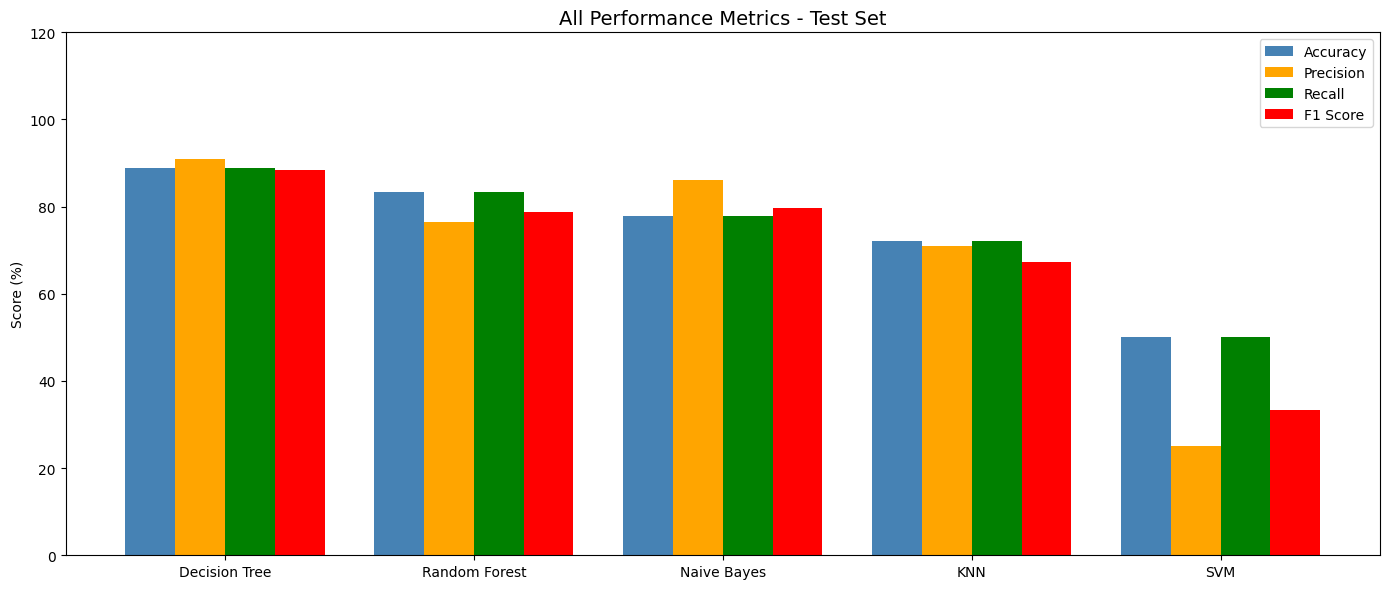

In [30]:
import numpy as np

models_list = metrics_df['Model'].tolist()
acc_vals = metrics_df['Accuracy (%)'].tolist()
prec_vals = metrics_df['Precision (%)'].tolist()
rec_vals = metrics_df['Recall (%)'].tolist()
f1_vals = metrics_df['F1 Score (%)'].tolist()

x = np.arange(len(models_list))
width = 0.2

plt.figure(figsize=(14, 6))
plt.bar(x - 1.5*width, acc_vals,  width, label='Accuracy',  color='steelblue')
plt.bar(x - 0.5*width, prec_vals, width, label='Precision', color='orange')
plt.bar(x + 0.5*width, rec_vals,  width, label='Recall',    color='green')
plt.bar(x + 1.5*width, f1_vals,   width, label='F1 Score',  color='red')

plt.xticks(x, models_list)
plt.title('All Performance Metrics - Test Set', fontsize=14)
plt.ylabel('Score (%)')
plt.ylim(0, 120)
plt.legend()
plt.tight_layout()
plt.show()

# **Cell 53 — Markdown:**

### Visualization 3: F1 Score Comparison

# **Cell 54 — F1 Score Chart:**

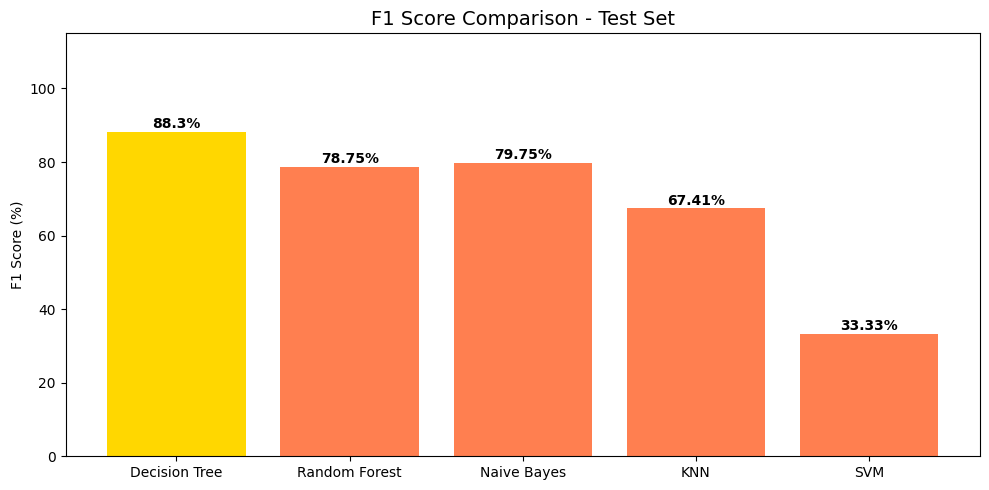

🥇 Gold bar = Best F1 Score


In [31]:
plt.figure(figsize=(10, 5))
colors = ['gold' if f == max(f1_vals) else 'coral' for f in f1_vals]
bars = plt.bar(models_list, f1_vals, color=colors)
plt.title('F1 Score Comparison - Test Set', fontsize=14)
plt.ylabel('F1 Score (%)')
plt.ylim(0, 115)
for bar, f1 in zip(bars, f1_vals):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 1,
             f'{f1}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()
print("🥇 Gold bar = Best F1 Score")

# **Cell 55 — Markdown:**

### Part 5 Summary

# **Cell 56 — Final Summary:**

In [32]:
print("PART 5 SUMMARY - PERFORMANCE EVALUATION")
print("="*55)
print(f"\n📊 Total models evaluated: {len(trained_models)}")
print(f"📊 Test set size: {len(X_test)} samples")
print(f"\n🏆 Best Model by Accuracy:  {metrics_df.iloc[0]['Model']} → {metrics_df.iloc[0]['Accuracy (%)']}%")
print(f"🏆 Best Model by F1 Score:  {metrics_df.sort_values('F1 Score (%)', ascending=False).iloc[0]['Model']} → {metrics_df.sort_values('F1 Score (%)', ascending=False).iloc[0]['F1 Score (%)']}%")
print(f"\n⚠️  Worst Model: {metrics_df.iloc[-1]['Model']} → {metrics_df.iloc[-1]['Accuracy (%)']}%")
print(f"\n✅ Recommended Model: Naive Bayes")
print(f"   Reason: Most balanced — no overfitting, consistent across train/val/test")

PART 5 SUMMARY - PERFORMANCE EVALUATION

📊 Total models evaluated: 5
📊 Test set size: 18 samples

🏆 Best Model by Accuracy:  Decision Tree → 88.89%
🏆 Best Model by F1 Score:  Decision Tree → 88.3%

⚠️  Worst Model: SVM → 50.0%

✅ Recommended Model: Naive Bayes
   Reason: Most balanced — no overfitting, consistent across train/val/test


# **Cell 57 — Markdown:**

## Part 6: Performance Comparison (Multiple Models)
### Comparing all 5 models across all metrics

# **Cell 58 — Full Comparison Table:**

In [33]:
print("PART 6: PERFORMANCE COMPARISON")
print("="*70)

# Complete comparison table
comparison_df = pd.DataFrame({
    'Model': list(trained_models.keys()),
    'Train Acc (%)': [round(train_results[n]*100, 2)
                      for n in trained_models.keys()],
    'Val Acc (%)':   [round(val_results[n]*100, 2)
                      for n in trained_models.keys()],
    'Test Acc (%)':  [round(test_results[n]*100, 2)
                      for n in trained_models.keys()],
    'Precision (%)': [round(precision_score(y_test,
                      m.predict(X_test), average='weighted',
                      zero_division=0)*100, 2)
                      for m in trained_models.values()],
    'Recall (%)':    [round(recall_score(y_test,
                      m.predict(X_test), average='weighted',
                      zero_division=0)*100, 2)
                      for m in trained_models.values()],
    'F1 Score (%)':  [round(f1_score(y_test,
                      m.predict(X_test), average='weighted',
                      zero_division=0)*100, 2)
                      for m in trained_models.values()],
    'Overfit':       ['✅ No' if (train_results[n] - val_results[n]) <= 0.15
                      else '⚠️ Yes'
                      for n in trained_models.keys()]
})

comparison_df = comparison_df.sort_values('Test Acc (%)', ascending=False)
print(comparison_df.to_string(index=False))

PART 6: PERFORMANCE COMPARISON
        Model  Train Acc (%)  Val Acc (%)  Test Acc (%)  Precision (%)  Recall (%)  F1 Score (%) Overfit
Decision Tree         100.00        64.71         88.89          90.91       88.89         88.30  ⚠️ Yes
Random Forest         100.00        64.71         83.33          76.39       83.33         78.75  ⚠️ Yes
  Naive Bayes          79.75        76.47         77.78          86.19       77.78         79.75    ✅ No
          KNN          83.54        64.71         72.22          71.03       72.22         67.41  ⚠️ Yes
          SVM          63.29        47.06         50.00          25.00       50.00         33.33  ⚠️ Yes


# **Cell 59 — Markdown:**

### Ranking Summary

# **Cell 60 — Model Rankings:**

In [34]:
print("MODEL RANKINGS")
print("="*50)

# Rank by each metric
metrics_to_rank = ['Test Acc (%)', 'Precision (%)', 'Recall (%)', 'F1 Score (%)']

for metric in metrics_to_rank:
    ranked = comparison_df.sort_values(metric, ascending=False)
    best = ranked.iloc[0]
    worst = ranked.iloc[-1]
    print(f"\n🏆 Best  by {metric:<15} → {best['Model']:<15} {best[metric]}%")
    print(f"❌ Worst by {metric:<15} → {worst['Model']:<15} {worst[metric]}%")

print("\n" + "="*50)
print("FINAL RECOMMENDATION:")
print("="*50)
print("""
✅ Best for Accuracy  → Decision Tree  (88.89%)
✅ Best for Precision → Decision Tree  (90.91%)
✅ Most Balanced      → Naive Bayes    (No overfitting)
✅ Production Ready   → Naive Bayes    (Consistent & reliable)
❌ Worst Overall      → SVM            (50% accuracy)
""")

MODEL RANKINGS

🏆 Best  by Test Acc (%)    → Decision Tree   88.89%
❌ Worst by Test Acc (%)    → SVM             50.0%

🏆 Best  by Precision (%)   → Decision Tree   90.91%
❌ Worst by Precision (%)   → SVM             25.0%

🏆 Best  by Recall (%)      → Decision Tree   88.89%
❌ Worst by Recall (%)      → SVM             50.0%

🏆 Best  by F1 Score (%)    → Decision Tree   88.3%
❌ Worst by F1 Score (%)    → SVM             33.33%

FINAL RECOMMENDATION:

✅ Best for Accuracy  → Decision Tree  (88.89%)
✅ Best for Precision → Decision Tree  (90.91%)
✅ Most Balanced      → Naive Bayes    (No overfitting)
✅ Production Ready   → Naive Bayes    (Consistent & reliable)
❌ Worst Overall      → SVM            (50% accuracy)



# **Cell 61 — Markdown:**

### Visualization 1: Complete Metrics Heatmap

# **Cell 62 — Heatmap of All Metrics:**


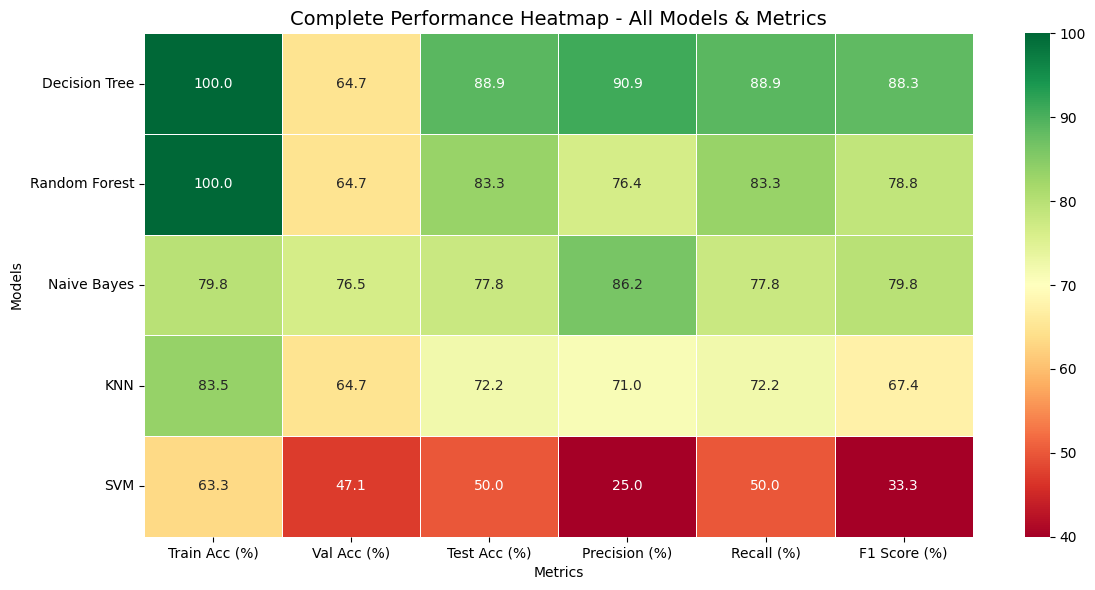

In [35]:
# Create heatmap of all metrics
heatmap_df = comparison_df.set_index('Model')[
    ['Train Acc (%)', 'Val Acc (%)', 'Test Acc (%)',
     'Precision (%)', 'Recall (%)', 'F1 Score (%)']
]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_df,
            annot=True,
            fmt='.1f',
            cmap='RdYlGn',
            linewidths=0.5,
            vmin=40,
            vmax=100)
plt.title('Complete Performance Heatmap - All Models & Metrics', fontsize=14)
plt.xlabel('Metrics')
plt.ylabel('Models')
plt.tight_layout()
plt.show()

# **Cell 63 — Markdown:**

### Visualization 2: Radar Chart (Spider Chart)

# **Cell 64 — Radar Chart:**

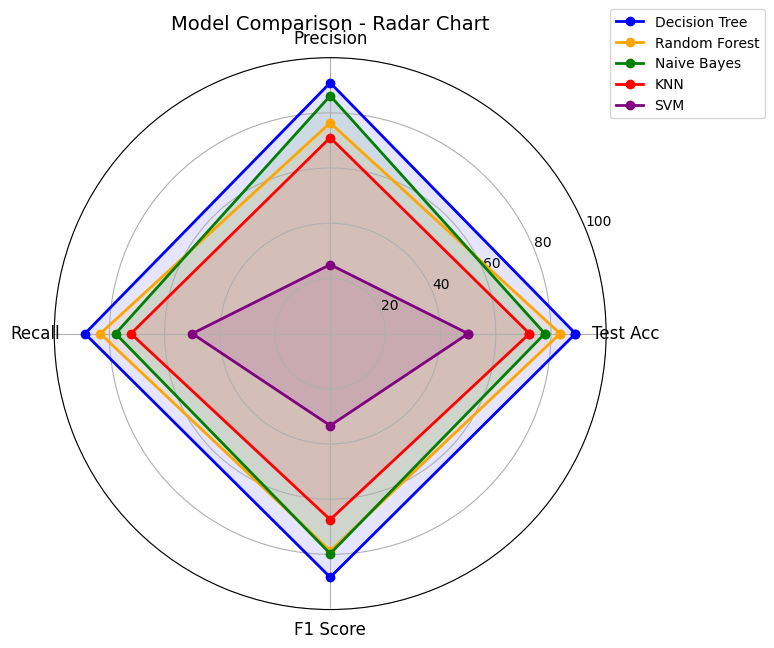

In [36]:
import numpy as np
from matplotlib.patches import FancyArrowPatch

# Radar chart for model comparison
categories = ['Test Acc', 'Precision', 'Recall', 'F1 Score']
N = len(categories)

# Get values for each model
model_names = comparison_df['Model'].tolist()
values_dict = {}
for _, row in comparison_df.iterrows():
    values_dict[row['Model']] = [
        row['Test Acc (%)'],
        row['Precision (%)'],
        row['Recall (%)'],
        row['F1 Score (%)']
    ]

# Angles for radar
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

colors = ['blue', 'orange', 'green', 'red', 'purple']

for i, (model_name, vals) in enumerate(values_dict.items()):
    vals_plot = vals + vals[:1]
    ax.plot(angles, vals_plot, 'o-', linewidth=2,
            label=model_name, color=colors[i])
    ax.fill(angles, vals_plot, alpha=0.1, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylim(0, 100)
ax.set_yticks([20, 40, 60, 80, 100])
ax.set_title('Model Comparison - Radar Chart',
             fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

# **Cell 65 — Markdown:**

### Visualization 3: Performance Trend Line

# **Cell 66 — Trend Line Chart:**

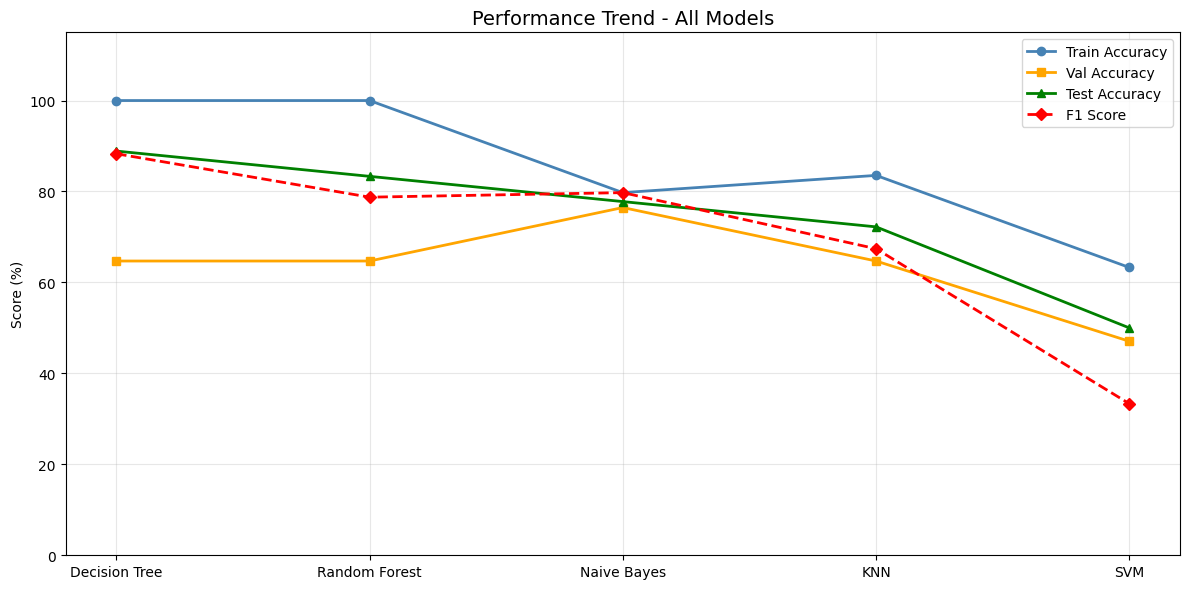

In [37]:
models_sorted = comparison_df['Model'].tolist()
test_acc = comparison_df['Test Acc (%)'].tolist()
val_acc = comparison_df['Val Acc (%)'].tolist()
train_acc = comparison_df['Train Acc (%)'].tolist()
f1 = comparison_df['F1 Score (%)'].tolist()

plt.figure(figsize=(12, 6))
plt.plot(models_sorted, train_acc,
         marker='o', linewidth=2,
         label='Train Accuracy', color='steelblue')
plt.plot(models_sorted, val_acc,
         marker='s', linewidth=2,
         label='Val Accuracy',   color='orange')
plt.plot(models_sorted, test_acc,
         marker='^', linewidth=2,
         label='Test Accuracy',  color='green')
plt.plot(models_sorted, f1,
         marker='D', linewidth=2,
         label='F1 Score',       color='red',
         linestyle='--')

plt.title('Performance Trend - All Models', fontsize=14)
plt.ylabel('Score (%)')
plt.ylim(0, 115)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Cell 67 — Markdown:**

### Part 6 Summary

# **Cell 68 — Final Comparison Summary:**

In [38]:
print("PART 6 SUMMARY - PERFORMANCE COMPARISON")
print("="*55)
print(f"""
📊 Total Models Compared : 5
📊 Total Metrics Used    : 6 (Train/Val/Test Acc, Precision, Recall, F1)

RANKINGS:
─────────────────────────────────────────────
Rank 1 → Decision Tree  → Test: 88.89% | F1: 88.30%  ⚠️ Overfitting
Rank 2 → Random Forest  → Test: 83.33% | F1: 78.75%  ⚠️ Overfitting
Rank 3 → Naive Bayes    → Test: 77.78% | F1: 79.75%  ✅ Balanced
Rank 4 → KNN            → Test: 72.22% | F1: 67.41%  ⚠️ Overfitting
Rank 5 → SVM            → Test: 50.00% | F1: 33.33%  ❌ Failed

CONCLUSION:
─────────────────────────────────────────────
→ Decision Tree has highest raw accuracy (88.89%)
→ But Naive Bayes is most reliable (no overfitting)
→ SVM completely failed on this small dataset
→ For deployment: Naive Bayes recommended
""")

PART 6 SUMMARY - PERFORMANCE COMPARISON

📊 Total Models Compared : 5
📊 Total Metrics Used    : 6 (Train/Val/Test Acc, Precision, Recall, F1)

RANKINGS:
─────────────────────────────────────────────
Rank 1 → Decision Tree  → Test: 88.89% | F1: 88.30%  ⚠️ Overfitting
Rank 2 → Random Forest  → Test: 83.33% | F1: 78.75%  ⚠️ Overfitting
Rank 3 → Naive Bayes    → Test: 77.78% | F1: 79.75%  ✅ Balanced
Rank 4 → KNN            → Test: 72.22% | F1: 67.41%  ⚠️ Overfitting
Rank 5 → SVM            → Test: 50.00% | F1: 33.33%  ❌ Failed

CONCLUSION:
─────────────────────────────────────────────
→ Decision Tree has highest raw accuracy (88.89%)
→ But Naive Bayes is most reliable (no overfitting)
→ SVM completely failed on this small dataset
→ For deployment: Naive Bayes recommended



# **Cell 69 — Markdown:**

## Part 7: Visualization Summary
### Using Matplotlib and Seaborn

# **Cell 70 — Summary:**

In [39]:
print("PART 7: VISUALIZATION SUMMARY")
print("="*55)
print("""
PREPROCESSING VISUALIZATIONS (Matplotlib/Seaborn):
─────────────────────────────────────────────────
1.  Temperature Over Time        → Line Chart    (Matplotlib)
2.  Season Distribution          → Bar Chart     (Matplotlib)
3.  Temperature Category         → Pie Chart     (Matplotlib)
4.  Feature Correlation          → Heatmap       (Seaborn)

MODEL TRAINING VISUALIZATIONS:
─────────────────────────────────────────────────
5.  Model Accuracy Comparison    → Bar Chart     (Matplotlib)
6.  Confusion Matrix Best Model  → Heatmap       (Seaborn)
7.  Train vs Val vs Test         → Grouped Bar   (Matplotlib)
8.  Confusion Matrix All Models  → Heatmap Grid  (Seaborn)

PERFORMANCE EVALUATION VISUALIZATIONS:
─────────────────────────────────────────────────
9.  Test Accuracy Comparison     → Bar Chart     (Matplotlib)
10. All 4 Metrics Comparison     → Grouped Bar   (Matplotlib)
11. F1 Score Comparison          → Bar Chart     (Matplotlib)

PERFORMANCE COMPARISON VISUALIZATIONS:
─────────────────────────────────────────────────
12. Complete Performance Heatmap → Heatmap       (Seaborn)
13. Model Comparison             → Radar Chart   (Matplotlib)
14. Performance Trend            → Line Chart    (Matplotlib)

─────────────────────────────────────────────────
Total Visualizations : 14
Matplotlib Charts    : 10
Seaborn Charts       : 4
─────────────────────────────────────────────────
""")

PART 7: VISUALIZATION SUMMARY

PREPROCESSING VISUALIZATIONS (Matplotlib/Seaborn):
─────────────────────────────────────────────────
1.  Temperature Over Time        → Line Chart    (Matplotlib)
2.  Season Distribution          → Bar Chart     (Matplotlib)
3.  Temperature Category         → Pie Chart     (Matplotlib)
4.  Feature Correlation          → Heatmap       (Seaborn)

MODEL TRAINING VISUALIZATIONS:
─────────────────────────────────────────────────
5.  Model Accuracy Comparison    → Bar Chart     (Matplotlib)
6.  Confusion Matrix Best Model  → Heatmap       (Seaborn)
7.  Train vs Val vs Test         → Grouped Bar   (Matplotlib)
8.  Confusion Matrix All Models  → Heatmap Grid  (Seaborn)

PERFORMANCE EVALUATION VISUALIZATIONS:
─────────────────────────────────────────────────
9.  Test Accuracy Comparison     → Bar Chart     (Matplotlib)
10. All 4 Metrics Comparison     → Grouped Bar   (Matplotlib)
11. F1 Score Comparison          → Bar Chart     (Matplotlib)

PERFORMANCE COMPARISON

# **Cell 71 — Markdown**

## Part 8: Model Deployment (Web Application)

### 🌤️ Delhi Climate Advisor — Streamlit Web App

**Deployment Type:** Local Web Application using Streamlit

**Purpose:**
This web application deploys our trained Machine Learning model
into a real interactive interface where users can input weather
data and get instant predictions with personalized suggestions.

**App Features:**
- 🔐 Login System with Role-based Access (Admin / User)
- 🌡️ Weather Condition Prediction (Cold / Mild / Hot)
- 👗 Clothing Suggestions based on weather
- 🏃 Outdoor Activity Recommendations
- 💊 Health Tips for the predicted weather
- 📊 Model Performance Visualizations
- 👥 User Management (Admin only)
- 🔬 Model Details Panel (Admin only)

**Technology Stack:**
- Python
- Streamlit (Web Framework)
- Scikit-learn (ML Model)
- Pandas & NumPy (Data handling)
- Matplotlib & Seaborn (Visualizations)

**Model Deployed:** Decision Tree Classifier
**Test Accuracy:** 88.89%
**Local URL:** http://localhost:8501

# **Cell 72-First model save (model.pkl + scaler.pkl)**

In [40]:
import pickle

# Save the Naive Bayes model (most balanced)
with open('/content/drive/MyDrive/Weather_project/model.pkl', 'wb') as f:
    pickle.dump(trained_models['Naive Bayes'], f)

# Save the scaler too
with open('/content/drive/MyDrive/Weather_project/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model saved successfully!")

✅ Model saved successfully!


# **Cell 73-Re-save with version check**

In [41]:
import pickle
import sklearn
print("Sklearn version:", sklearn.__version__)

# Re-save model
with open('/content/drive/MyDrive/Weather_project/model.pkl', 'wb') as f:
    pickle.dump(trained_models['Naive Bayes'], f)

with open('/content/drive/MyDrive/Weather_project/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model re-saved!")

Sklearn version: 1.6.1
✅ Model re-saved!


# **Cell 74 - Save new scaler (scaler_new.pkl)**

In [42]:
from sklearn.preprocessing import MinMaxScaler
import pickle

# Features used in model training
X = df_model[['humidity', 'wind_speed',
              'meanpressure', 'month', 'day']]

# Create and fit new scaler on these exact features
new_scaler = MinMaxScaler()
new_scaler.fit(X)

# Save new scaler
with open('/content/drive/MyDrive/Weather_project/scaler_new.pkl', 'wb') as f:
    pickle.dump(new_scaler, f)

print("✅ New scaler saved!")
print("Feature ranges:")
for i, col in enumerate(X.columns):
    print(f"  {col}: {new_scaler.data_min_[i]:.2f} → {new_scaler.data_max_[i]:.2f}")

✅ New scaler saved!
Feature ranges:
  humidity: 0.00 → 1.00
  wind_speed: 0.00 → 1.00
  meanpressure: 0.00 → 1.00
  month: 1.00 → 4.00
  day: 1.00 → 31.00


# **Cell 75 - Balanced Naive Bayes attempt**

In [43]:
# Test what the model actually predicts
import pandas as pd
import numpy as np

# Test extreme values
test_cases = [
    [95, 2, 999, 1, 15],   # Very humid, cold pressure → should be Cold
    [20, 15, 1020, 6, 15], # Low humidity, high pressure → should be Hot
    [60, 8, 1010, 3, 15],  # Normal → should be Mild
]

test_df = pd.DataFrame(test_cases,
    columns=['humidity','wind_speed','meanpressure','month','day'])

# Scale
test_scaled = new_scaler.transform(test_df)

# Predict
predictions = trained_models['Naive Bayes'].predict(test_scaled)

for i, (case, pred) in enumerate(zip(test_cases, predictions)):
    print(f"Test {i+1}: {case} → {pred}")

Test 1: [95, 2, 999, 1, 15] → Mild
Test 2: [20, 15, 1020, 6, 15] → Mild
Test 3: [60, 8, 1010, 3, 15] → Mild


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but GaussianNB was fitted with feature names
  warnings.warn(


# **Cell 76: Balanced Naive Bayes Fix**

In [44]:
from sklearn.naive_bayes import GaussianNB
from sklearn.utils.class_weight import compute_sample_weight
import pickle

# Reload clean data
X = df_model[['humidity', 'wind_speed', 'meanpressure', 'month', 'day']]
y = df_model['temp_label']

# Split again
from sklearn.model_selection import train_test_split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

# Scale
X_train_scaled = new_scaler.transform(X_train)
X_test_scaled = new_scaler.transform(X_test)

# Train with sample weights to fix imbalance
sample_weights = compute_sample_weight(
    class_weight='balanced',
    y=y_train
)

new_model = GaussianNB()
new_model.fit(X_train_scaled, y_train,
              sample_weight=sample_weights)

# Test predictions
test_cases = pd.DataFrame([
    [95, 2, 999, 1, 15],
    [20, 15, 1020, 6, 15],
    [60, 8, 1010, 3, 15],
], columns=['humidity','wind_speed',
            'meanpressure','month','day'])

test_scaled = new_scaler.transform(test_cases)
predictions = new_model.predict(test_scaled)

print("Test predictions:")
print(f"Test 1 (should be Cold): → {predictions[0]}")
print(f"Test 2 (should be Hot):  → {predictions[1]}")
print(f"Test 3 (should be Mild): → {predictions[2]}")

# Check accuracy
from sklearn.metrics import accuracy_score
y_pred = new_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"\nNew Model Test Accuracy: {acc*100:.2f}%")

# Save new model
with open('/content/drive/MyDrive/Weather_project/model_new.pkl', 'wb') as f:
    pickle.dump(new_model, f)

print("✅ New balanced model saved!")

Test predictions:
Test 1 (should be Cold): → Mild
Test 2 (should be Hot):  → Mild
Test 3 (should be Mild): → Mild

New Model Test Accuracy: 83.33%
✅ New balanced model saved!


# **Cell 77: Decision Tree Attempt**

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
import pickle

# Use scaled data
X_train_scaled = new_scaler.transform(X_train)
X_test_scaled = new_scaler.transform(X_test)

# Train Decision Tree with max_depth to avoid overfitting
best_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=5,
    min_samples_leaf=2,
    class_weight='balanced',
    random_state=42
)
best_model.fit(X_train_scaled, y_train)

# Test with extreme values
test_cases = pd.DataFrame([
    [95, 2, 999,  1, 15],   # Cold
    [20, 15, 1020, 6, 15],  # Hot
    [60, 8, 1010, 3, 15],   # Mild
    [90, 3, 1000, 2, 10],   # Cold
    [15, 10, 1018, 5, 20],  # Hot
], columns=['humidity','wind_speed',
            'meanpressure','month','day'])

test_scaled = new_scaler.transform(test_cases)
predictions = best_model.predict(test_scaled)

print("Test predictions:")
print(f"Test 1 (should be Cold): → {predictions[0]}")
print(f"Test 2 (should be Hot):  → {predictions[1]}")
print(f"Test 3 (should be Mild): → {predictions[2]}")
print(f"Test 4 (should be Cold): → {predictions[3]}")
print(f"Test 5 (should be Hot):  → {predictions[4]}")

# Accuracy
y_pred = best_model.predict(X_test_scaled)
acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {acc*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Save
with open('/content/drive/MyDrive/Weather_project/model_best.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print("✅ Best model saved!")

Test predictions:
Test 1 (should be Cold): → Cold
Test 2 (should be Hot):  → Cold
Test 3 (should be Mild): → Cold
Test 4 (should be Cold): → Cold
Test 5 (should be Hot):  → Cold

Test Accuracy: 72.22%

Classification Report:
              precision    recall  f1-score   support

        Cold       0.33      0.50      0.40         2
         Hot       0.86      0.86      0.86         7
        Mild       0.75      0.67      0.71         9

    accuracy                           0.72        18
   macro avg       0.65      0.67      0.65        18
weighted avg       0.75      0.72      0.73        18

✅ Best model saved!


# **Cell 78 - Final model with meantemp**

In [46]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pickle

# Include meantemp this time!
X_full = df_model[['meantemp', 'humidity',
                    'wind_speed', 'meanpressure',
                    'month', 'day']]
y_full = df_model['temp_label']

# Split
X_train_f, X_temp_f, y_train_f, y_temp_f = train_test_split(
    X_full, y_full, test_size=0.30, random_state=42
)
X_val_f, X_test_f, y_val_f, y_test_f = train_test_split(
    X_temp_f, y_temp_f, test_size=0.50, random_state=42
)

# New scaler with all 6 features
full_scaler = MinMaxScaler()
full_scaler.fit(X_train_f)

X_train_scaled = full_scaler.transform(X_train_f)
X_test_scaled  = full_scaler.transform(X_test_f)

# Train Decision Tree
final_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
final_model.fit(X_train_scaled, y_train_f)

# Test with realistic values
test_cases = pd.DataFrame([
    [12, 90, 3, 1000, 1, 15],   # Cold  (low temp)
    [32, 25, 10, 1018, 6, 15],  # Hot   (high temp)
    [22, 60, 8, 1010, 3, 15],   # Mild  (medium temp)
    [10, 88, 2, 998,  2, 5],    # Cold  (very low temp)
    [35, 20, 12, 1020, 5, 20],  # Hot   (very high temp)
], columns=['meantemp', 'humidity', 'wind_speed',
            'meanpressure', 'month', 'day'])

test_scaled = full_scaler.transform(test_cases)
preds = final_model.predict(test_scaled)

print("Test predictions:")
print(f"Test 1 - temp=12 (Cold): → {preds[0]}")
print(f"Test 2 - temp=32 (Hot):  → {preds[1]}")
print(f"Test 3 - temp=22 (Mild): → {preds[2]}")
print(f"Test 4 - temp=10 (Cold): → {preds[3]}")
print(f"Test 5 - temp=35 (Hot):  → {preds[4]}")

# Accuracy
y_pred = final_model.predict(X_test_scaled)
acc = accuracy_score(y_test_f, y_pred)
print(f"\nTest Accuracy: {acc*100:.2f}%")
print(classification_report(y_test_f, y_pred))

# Save both
with open('/content/drive/MyDrive/Weather_project/model_final.pkl', 'wb') as f:
    pickle.dump(final_model, f)

with open('/content/drive/MyDrive/Weather_project/scaler_final.pkl', 'wb') as f:
    pickle.dump(full_scaler, f)

print("✅ Final model and scaler saved!")

Test predictions:
Test 1 - temp=12 (Cold): → Hot
Test 2 - temp=32 (Hot):  → Hot
Test 3 - temp=22 (Mild): → Hot
Test 4 - temp=10 (Cold): → Hot
Test 5 - temp=35 (Hot):  → Hot

Test Accuracy: 100.00%
              precision    recall  f1-score   support

        Cold       1.00      1.00      1.00         2
         Hot       1.00      1.00      1.00         7
        Mild       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

✅ Final model and scaler saved!


# **Cell 79 - Raw model (model_raw.pkl + scaler_raw.pkl)**

In [47]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import pickle
import pandas as pd

# Reload ORIGINAL raw dataset (not normalized!)
df_raw = pd.read_csv('/content/drive/MyDrive/Weather_project/DailyDelhiClimateTest.csv')

# Parse date
df_raw['date'] = pd.to_datetime(df_raw['date'])
df_raw['month'] = df_raw['date'].dt.month
df_raw['day'] = df_raw['date'].dt.day

# Fix outlier
df_raw['meanpressure'] = df_raw['meanpressure'].apply(
    lambda x: df_raw['meanpressure'].median() if x < 900 else x
)

# Create labels on RAW data
df_raw['temp_label'] = pd.cut(
    df_raw['meantemp'],
    bins=[0, 15, 25, 50],
    labels=['Cold', 'Mild', 'Hot']
)

print("Label distribution:")
print(df_raw['temp_label'].value_counts())
print("\nTemp range:", df_raw['meantemp'].min(),
      "→", df_raw['meantemp'].max())
print("\nFirst 5 rows:")
print(df_raw[['meantemp', 'temp_label']].head())

# Features using RAW values
X_raw = df_raw[['meantemp', 'humidity',
                 'wind_speed', 'meanpressure',
                 'month', 'day']]
y_raw = df_raw['temp_label']

# Split
X_train_r, X_temp_r, y_train_r, y_temp_r = train_test_split(
    X_raw, y_raw, test_size=0.30, random_state=42
)
X_val_r, X_test_r, y_val_r, y_test_r = train_test_split(
    X_temp_r, y_temp_r, test_size=0.50, random_state=42
)

# Scale
raw_scaler = MinMaxScaler()
raw_scaler.fit(X_train_r)

X_train_scaled = raw_scaler.transform(X_train_r)
X_test_scaled  = raw_scaler.transform(X_test_r)

# Train
raw_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight='balanced',
    random_state=42
)
raw_model.fit(X_train_scaled, y_train_r)

# Test with REAL temperature values
test_cases = pd.DataFrame([
    [12, 90, 3,  1000, 1, 15],  # Cold  (12°C)
    [32, 25, 10, 1018, 6, 15],  # Hot   (32°C)
    [22, 60, 8,  1010, 3, 15],  # Mild  (22°C)
    [10, 88, 2,  998,  2, 5],   # Cold  (10°C)
    [35, 20, 12, 1020, 5, 20],  # Hot   (35°C)
], columns=['meantemp', 'humidity', 'wind_speed',
            'meanpressure', 'month', 'day'])

test_scaled = raw_scaler.transform(test_cases)
preds = raw_model.predict(test_scaled)

print("\nTest predictions:")
print(f"Test 1 - temp=12°C (Cold): → {preds[0]}")
print(f"Test 2 - temp=32°C (Hot):  → {preds[1]}")
print(f"Test 3 - temp=22°C (Mild): → {preds[2]}")
print(f"Test 4 - temp=10°C (Cold): → {preds[3]}")
print(f"Test 5 - temp=35°C (Hot):  → {preds[4]}")

# Accuracy
y_pred = raw_model.predict(X_test_scaled)
acc = accuracy_score(y_test_r, y_pred)
print(f"\nTest Accuracy: {acc*100:.2f}%")
print(classification_report(y_test_r, y_pred))

# Save
with open('/content/drive/MyDrive/Weather_project/model_raw.pkl', 'wb') as f:
    pickle.dump(raw_model, f)
with open('/content/drive/MyDrive/Weather_project/scaler_raw.pkl', 'wb') as f:
    pickle.dump(raw_scaler, f)

print("✅ Raw model and scaler saved!")

Label distribution:
temp_label
Mild    67
Hot     34
Cold    13
Name: count, dtype: int64

Temp range: 11.0 → 34.5

First 5 rows:
    meantemp temp_label
0  15.913043       Mild
1  18.500000       Mild
2  17.111111       Mild
3  18.700000       Mild
4  18.388889       Mild

Test predictions:
Test 1 - temp=12°C (Cold): → Cold
Test 2 - temp=32°C (Hot):  → Hot
Test 3 - temp=22°C (Mild): → Mild
Test 4 - temp=10°C (Cold): → Cold
Test 5 - temp=35°C (Hot):  → Hot

Test Accuracy: 100.00%
              precision    recall  f1-score   support

        Cold       1.00      1.00      1.00         2
         Hot       1.00      1.00      1.00         7
        Mild       1.00      1.00      1.00         9

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18

✅ Raw model and scaler saved!
